# Classical lifetime fitting and evaluation

This notebook loads a synthetic mono-exponential TCSPC decay generated in the previous notebook.

The workflow is:

1. Load the simulated photon-count data.
2. Select initial parameter guesses.
3. Fit a mono-exponential model using nonlinear least squares.
4. Generate the fitted signal.
5. Compare the fitted lifetime with the known true lifetime.
6. Calculate raw and Poisson-scaled residuals.
7. Inspect whether the residuals appear randomly distributed.

The current model does not include an instrument response function.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tcspc_toolkit.evaluation import (
    generate_fitted_signal,
    calculate_residuals,
    calculate_reduced_residuals,
    calculate_absolute_lifetime_error,
    calculate_relative_lifetime_error,
)
from tcspc_toolkit.fitting import fit_monoexponential_decay

In [2]:
project_root = Path.cwd().parent

input_file = (
    project_root
    / "data"
    / "generated"
    / "ideal_tcspc_decay.csv"
)

print(f"Project root: {project_root}")
print(f"Input file:   {input_file}")

if not input_file.exists():
    raise FileNotFoundError(
        f"Input data file was not found: {input_file}"
    )

Project root: C:\Users\Yevhenii\PycharmProjects\scientific-python-transition
Input file:   C:\Users\Yevhenii\PycharmProjects\scientific-python-transition\data\generated\ideal_tcspc_decay.csv


In [3]:
decay_data = pd.read_csv(input_file)

decay_data.head()
decay_data.info()
print(f"Number of rows:    {decay_data.shape[0]}")
print(f"Number of columns: {decay_data.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time_ns           512 non-null    float64
 1   expected_counts   512 non-null    float64
 2   measured_counts   512 non-null    int64  
 3   lifetime_true_ns  512 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 16.1 KB
Number of rows:    512
Number of columns: 4


In [4]:
required_columns = {
    "time_ns",
    "measured_counts",
    "lifetime_true_ns",
}

missing_columns = required_columns - set(decay_data.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

In [5]:
time_ns = decay_data["time_ns"].to_numpy(
    dtype=np.float64
)

measured_counts = decay_data["measured_counts"].to_numpy(
    dtype=np.float64
)

lifetime_true_ns = float(
    decay_data["lifetime_true_ns"].iloc[0]
)

In [6]:
unique_true_lifetimes = (
    decay_data["lifetime_true_ns"].unique()
)

print(
    f"Unique true lifetime values: "
    f"{unique_true_lifetimes}"
)

if len(unique_true_lifetimes) != 1:
    raise ValueError(
        "The input file contains more than one true lifetime."
    )

Unique true lifetime values: [2.5]


In [7]:
print("Time-array shape:  ", time_ns.shape)
print("Count-array shape: ", measured_counts.shape)
print("True lifetime:     ", lifetime_true_ns, "ns")

print()
print("First five time values:")
print(time_ns[:5])

print()
print("First five measured counts:")
print(measured_counts[:5])

Time-array shape:   (512,)
Count-array shape:  (512,)
True lifetime:      2.5 ns

First five time values:
[0.         0.03913894 0.07827789 0.11741683 0.15655577]

First five measured counts:
[10090.  9971.  9542.  9624.  9271.]


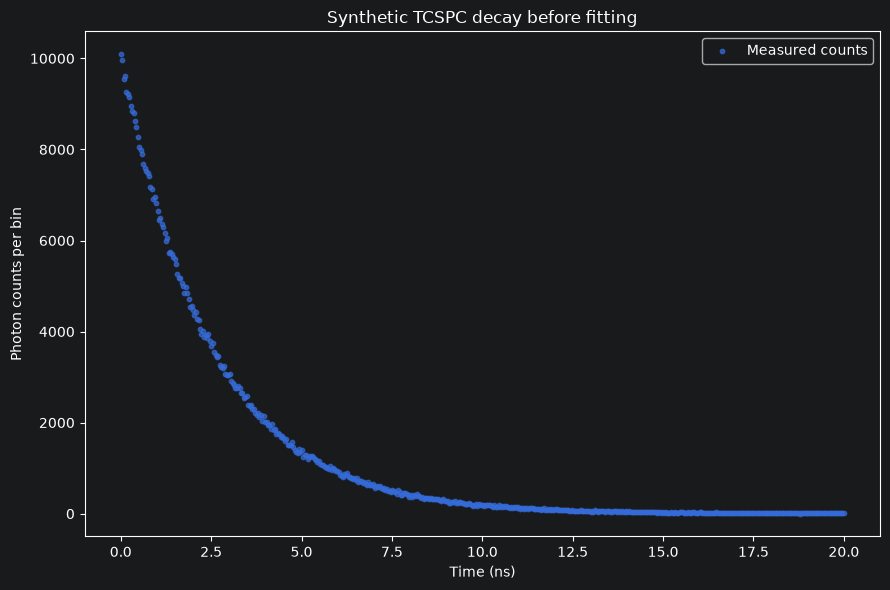

In [8]:
plt.figure(figsize=(9, 6))

plt.scatter(
    time_ns,
    measured_counts,
    s=10,
    alpha=0.7,
    label="Measured counts",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts per bin")
plt.title("Synthetic TCSPC decay before fitting")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
number_of_background_bins = 50

tail_counts = measured_counts[
    -number_of_background_bins:
]

initial_background_guess = float(
    np.median(tail_counts)
)

print(
    f"Initial background guess: "
    f"{initial_background_guess:.2f} counts"
)

Initial background guess: 9.50 counts


In [10]:
initial_amplitude_guess = float(
    measured_counts.max()
    - initial_background_guess
)

print(
    f"Maximum measured count: "
    f"{measured_counts.max():.2f}"
)

print(
    f"Initial amplitude guess: "
    f"{initial_amplitude_guess:.2f}"
)

Maximum measured count: 10090.00
Initial amplitude guess: 10080.50


In [11]:
initial_lifetime_guess_ns = 2.0
# TODO: implement an automatic lifetime estimate from the decay shape

print(
    f"Initial lifetime guess: "
    f"{initial_lifetime_guess_ns:.2f} ns"
)

Initial lifetime guess: 2.00 ns


In [12]:
initial_guess = (
    initial_amplitude_guess,
    initial_lifetime_guess_ns,
    initial_background_guess,
)

print("Initial parameter guesses")
print("-------------------------")
print(f"Amplitude:  {initial_guess[0]:.2f}")
print(f"Lifetime:   {initial_guess[1]:.2f} ns")
print(f"Background: {initial_guess[2]:.2f}")

Initial parameter guesses
-------------------------
Amplitude:  10080.50
Lifetime:   2.00 ns
Background: 9.50


In [13]:
fit_result = fit_monoexponential_decay(
    time=time_ns,
    counts=measured_counts,
    initial_guess=initial_guess,
)

fit_result

LifetimeFitResult(amplitude=10001.595996478683, lifetime=2.4940796599124506, background=5.980875598565766, amplitude_std=8.543321348178662, lifetime_std=0.0037032489872893767, background_std=2.1537713224833697)

In [14]:
print("Fitted parameters")
print("-----------------")

print(
    f"Amplitude:  "
    f"{fit_result.amplitude:.4f} ± "
    f"{fit_result.amplitude_std:.4f}"
)

print(
    f"Lifetime:   "
    f"{fit_result.lifetime:.6f} ± "
    f"{fit_result.lifetime_std:.6f} ns"
)

print(
    f"Background: "
    f"{fit_result.background:.4f} ± "
    f"{fit_result.background_std:.4f} counts"
)

Fitted parameters
-----------------
Amplitude:  10001.5960 ± 8.5433
Lifetime:   2.494080 ± 0.003703 ns
Background: 5.9809 ± 2.1538 counts


In [15]:
fitted_counts = generate_fitted_signal(
    time=time_ns,
    fit_result=fit_result,
)

print("Fitted-signal shape:", fitted_counts.shape)
print("First five fitted values:")
print(fitted_counts[:5])

Fitted-signal shape: (512,)
First five fitted values:
[10007.57687208  9851.84951832  9698.54687845  9547.63119907
  9399.0653146 ]


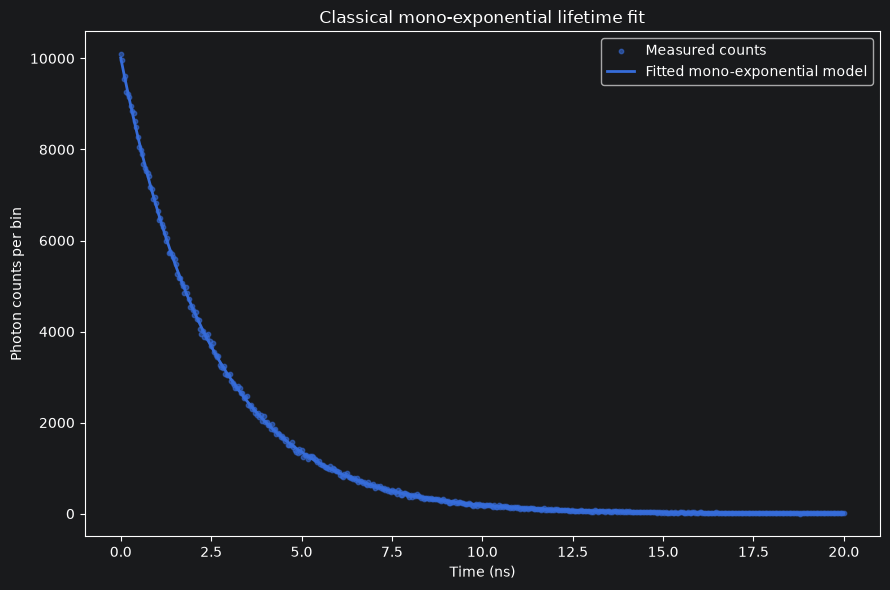

In [16]:
plt.figure(figsize=(9, 6))

plt.scatter(
    time_ns,
    measured_counts,
    s=10,
    alpha=0.6,
    label="Measured counts",
)

plt.plot(
    time_ns,
    fitted_counts,
    linewidth=2,
    label="Fitted mono-exponential model",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts per bin")
plt.title("Classical mono-exponential lifetime fit")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
absolute_lifetime_error_ns = (
    calculate_absolute_lifetime_error(
        true_lifetime=lifetime_true_ns,
        estimated_lifetime=fit_result.lifetime,
    )
)

relative_lifetime_error = (
    calculate_relative_lifetime_error(
        true_lifetime=lifetime_true_ns,
        estimated_lifetime=fit_result.lifetime,
    )
)

relative_lifetime_error_percent = (
    relative_lifetime_error * 100.0
)

In [18]:
print("Lifetime evaluation")
print("-------------------")

print(
    f"True lifetime:       "
    f"{lifetime_true_ns:.6f} ns"
)

print(
    f"Estimated lifetime:  "
    f"{fit_result.lifetime:.6f} ns"
)

print(
    f"Standard error:      "
    f"{fit_result.lifetime_std:.6f} ns"
)

print(
    f"Absolute error:      "
    f"{absolute_lifetime_error_ns:.6f} ns"
)

print(
    f"Relative error:      "
    f"{relative_lifetime_error_percent:.3f}%"
)

Lifetime evaluation
-------------------
True lifetime:       2.500000 ns
Estimated lifetime:  2.494080 ns
Standard error:      0.003703 ns
Absolute error:      0.005920 ns
Relative error:      0.237%


In [19]:
residuals = calculate_residuals(
    observed=measured_counts,
    fitted=fitted_counts,
)

for index in range(5):
    print(
        f"Bin {index}: "
        f"measured = {measured_counts[index]:.2f}, "
        f"fitted = {fitted_counts[index]:.2f}, "
        f"residual = {residuals[index]:.2f}"
    )

Bin 0: measured = 10090.00, fitted = 10007.58, residual = 82.42
Bin 1: measured = 9971.00, fitted = 9851.85, residual = 119.15
Bin 2: measured = 9542.00, fitted = 9698.55, residual = -156.55
Bin 3: measured = 9624.00, fitted = 9547.63, residual = 76.37
Bin 4: measured = 9271.00, fitted = 9399.07, residual = -128.07


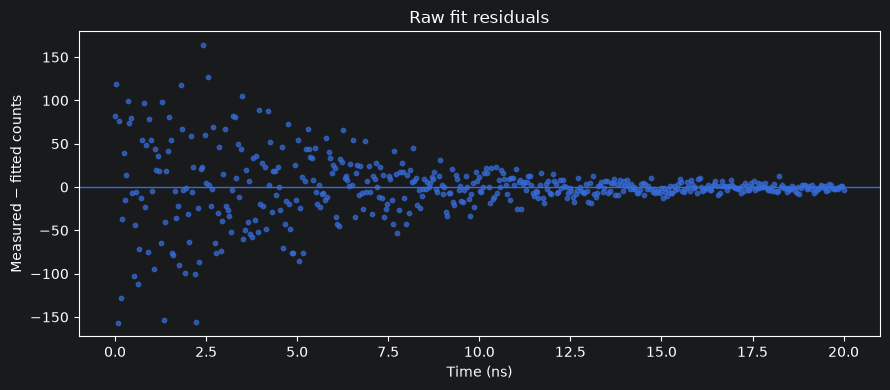

In [20]:
plt.figure(figsize=(9, 4))

plt.scatter(
    time_ns,
    residuals,
    s=10,
    alpha=0.7,
)

plt.axhline(
    y=0.0,
    linewidth=1,
)

plt.xlabel("Time (ns)")
plt.ylabel("Measured − fitted counts")
plt.title("Raw fit residuals")
plt.tight_layout()
plt.show()

In [21]:
reduced_residuals = calculate_reduced_residuals(
    observed=measured_counts,
    fitted=fitted_counts,
)

for index in range(5):
    print(
        f"Bin {index}: "
        f"raw residual = {residuals[index]:.2f}, "
        f"reduced residual = "
        f"{reduced_residuals[index]:.3f}"
    )

Bin 0: raw residual = 82.42, reduced residual = 0.824
Bin 1: raw residual = 119.15, reduced residual = 1.200
Bin 2: raw residual = -156.55, reduced residual = -1.590
Bin 3: raw residual = 76.37, reduced residual = 0.782
Bin 4: raw residual = -128.07, reduced residual = -1.321


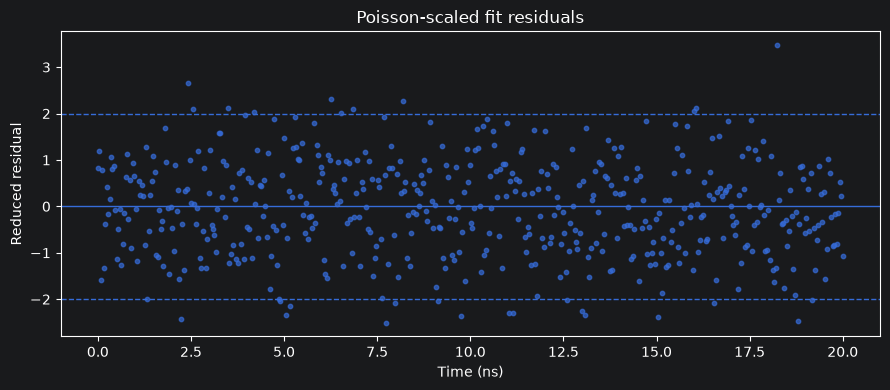

In [22]:
plt.figure(figsize=(9, 4))

plt.scatter(
    time_ns,
    reduced_residuals,
    s=10,
    alpha=0.7,
)

plt.axhline(
    y=0.0,
    linewidth=1,
)

plt.axhline(
    y=2.0,
    linewidth=1,
    linestyle="--",
)

plt.axhline(
    y=-2.0,
    linewidth=1,
    linestyle="--",
)

plt.xlabel("Time (ns)")
plt.ylabel("Reduced residual")
plt.title("Poisson-scaled fit residuals")
plt.tight_layout()
plt.show()

In [23]:
mean_raw_residual = float(
    np.mean(residuals)
)

mean_reduced_residual = float(
    np.mean(reduced_residuals)
)

reduced_residual_std = float(
    np.std(
        reduced_residuals,
        ddof=1,
    )
)

print(
    f"Mean raw residual: "
    f"{mean_raw_residual:.6f}"
)

print(
    f"Mean reduced residual: "
    f"{mean_reduced_residual:.6f}"
)

print(
    f"Reduced-residual standard deviation: "
    f"{reduced_residual_std:.6f}"
)

Mean raw residual: -0.000003
Mean reduced residual: -0.053292
Reduced-residual standard deviation: 1.027161


In [24]:
number_positive = int(
    np.sum(reduced_residuals > 0)
)

number_negative = int(
    np.sum(reduced_residuals < 0)
)

number_zero = int(
    np.sum(reduced_residuals == 0)
)

print(f"Positive residuals: {number_positive}")
print(f"Negative residuals: {number_negative}")
print(f"Zero residuals:     {number_zero}")

Positive residuals: 242
Negative residuals: 270
Zero residuals:     0


In [25]:
residual_signs = np.sign(
    reduced_residuals
)

nonzero_signs = residual_signs[
    residual_signs != 0
]

number_of_sign_changes = int(
    np.sum(
        nonzero_signs[1:]
        != nonzero_signs[:-1]
    )
)

print(
    f"Number of residual sign changes: "
    f"{number_of_sign_changes}"
)

Number of residual sign changes: 237


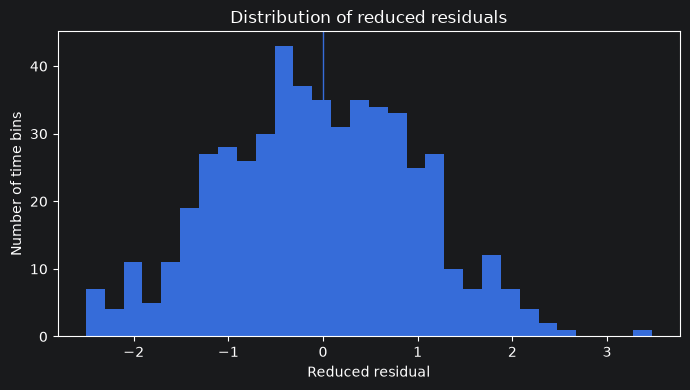

In [26]:
plt.figure(figsize=(7, 4))

plt.hist(
    reduced_residuals,
    bins=30,
)

plt.axvline(
    x=0.0,
    linewidth=1,
)

plt.xlabel("Reduced residual")
plt.ylabel("Number of time bins")
plt.title("Distribution of reduced residuals")
plt.tight_layout()
plt.show()

In [27]:
decay_data["fitted_counts"] = fitted_counts
decay_data["residual_counts"] = residuals
decay_data["reduced_residual"] = reduced_residuals

decay_data.head()

,time_ns,expected_counts,measured_counts,lifetime_true_ns,fitted_counts,residual_counts,reduced_residual
0,0.000000,10005.000000,10090,2.5,10007.576872,82.423128,0.823919
1,0.039139,9849.663342,9971,2.5,9851.849518,119.150482,1.200430
2,0.078278,9696.739632,9542,2.5,9698.546878,-156.546878,-1.589612
3,0.117417,9546.191388,9624,2.5,9547.631199,76.368801,0.781570
4,0.156556,9397.981710,9271,2.5,9399.065315,-128.065315,-1.320959


In [28]:
fit_summary = pd.DataFrame(
    {
        "true_lifetime_ns": [
            lifetime_true_ns
        ],
        "estimated_lifetime_ns": [
            fit_result.lifetime
        ],
        "lifetime_standard_error_ns": [
            fit_result.lifetime_std
        ],
        "absolute_lifetime_error_ns": [
            absolute_lifetime_error_ns
        ],
        "relative_lifetime_error": [
            relative_lifetime_error
        ],
        "relative_lifetime_error_percent": [
            relative_lifetime_error_percent
        ],
        "fitted_amplitude": [
            fit_result.amplitude
        ],
        "amplitude_standard_error": [
            fit_result.amplitude_std
        ],
        "fitted_background": [
            fit_result.background
        ],
        "background_standard_error": [
            fit_result.background_std
        ],
        "mean_reduced_residual": [
            mean_reduced_residual
        ],
        "std_reduced_residual": [
            reduced_residual_std
        ],
        "positive_residual_count": [
            number_positive
        ],
        "negative_residual_count": [
            number_negative
        ],
        "residual_sign_changes": [
            number_of_sign_changes
        ],
    }
)

fit_summary

,true_lifetime_ns,estimated_lifetime_ns,lifetime_standard_error_ns,absolute_lifetime_error_ns,relative_lifetime_error,relative_lifetime_error_percent,fitted_amplitude,amplitude_standard_error,fitted_background,background_standard_error,mean_reduced_residual,std_reduced_residual,positive_residual_count,negative_residual_count,residual_sign_changes
0,2.5,2.49408,0.003703,0.00592,0.002368,0.236814,10001.595996,8.543321,5.980876,2.153771,-0.053292,1.027161,242,270,237


In [29]:
output_directory = (
    project_root
    / "data"
    / "generated"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

evaluated_curve_file = (
    output_directory
    / "ideal_tcspc_decay_evaluated.csv"
)

decay_data.to_csv(
    evaluated_curve_file,
    index=False,
)

print(
    f"Evaluated curve saved to: "
    f"{evaluated_curve_file}"
)

Evaluated curve saved to: C:\Users\Yevhenii\PycharmProjects\scientific-python-transition\data\generated\ideal_tcspc_decay_evaluated.csv


In [30]:
fit_summary_file = (
    output_directory
    / "ideal_tcspc_decay_fit_summary.csv"
)

fit_summary.to_csv(
    fit_summary_file,
    index=False,
)

print(
    f"Fit summary saved to: "
    f"{fit_summary_file}"
)

Fit summary saved to: C:\Users\Yevhenii\PycharmProjects\scientific-python-transition\data\generated\ideal_tcspc_decay_fit_summary.csv


## Interpretation

The nonlinear least-squares procedure estimated the amplitude, lifetime, and constant background of the synthetic decay.

The fitted lifetime was compared with the known lifetime used to generate the synthetic data. The absolute error measures the difference in nanoseconds, while the relative error expresses the same difference relative to the true lifetime.

Raw residuals were calculated as measured counts minus fitted counts. Because Poisson count variance changes with the expected count level, Poisson-scaled residuals were also calculated by dividing the raw residuals by the square root of the fitted count.

A visually adequate fit should produce residuals that fluctuate above and below zero without a systematic dependence on time.

## Limitations

The present fit is an unweighted nonlinear least-squares baseline. The simulated and fitted model does not yet include:

- an instrument response function;
- temporal alignment;
- reconvolution;
- a direct Poisson likelihood;
- multi-exponential decay;
- detector artefacts.

The covariance-based parameter standard errors should therefore be treated as preliminary uncertainty estimates.